In [8]:
import os
import sys
import pathlib
import math
import numpy as np
import matplotlib.pyplot as plt
import qpc.tools as tools
from qpc.tools import mv
from qpc import evolution
from concurrent.futures import ProcessPoolExecutor

In [2]:
ed_list = np.linspace(-1, 1, num=10)

In [6]:
# numerically exact solution on initial time interval for checking the correctness

def solve_for_ed(e_d):

    e = 1     # on-site energy
    h = 0.05  # hopping
    U = 1

    n_qua = 8
    m_imp = 2
    m_env = 10

    m = tools.fermion_2lead_fermion_model(num_impurity_modes = m_imp, num_reservoir_modes = m_env, max_num_quanta = n_qua)

    tmax = 40 #100
    dt = 0.01
    t = np.arange(start = 0, stop = tmax, step = dt)
    nt = t.size

    nq = np.zeros(nt)

    H_const = e_d * m.d_dag[1] @ m.d[1] - e_d * m.d_dag[0] @ m.d[0] \
        + U * m.d_dag[1] @ m.d[1] - U * m.d_dag[0] @ m.d[0] @ m.d_dag[1] @ m.d[1] \
        + h * m.d_dag[1] @ m.d_dag[0] + h *  m.d[0] @ m.d[1] \
        - h * m.d_dag[0] @ m.l[0]  - h * m.l_dag[0] @ m.d[0] \
        + h * m.r_dag[0] @ m.d[1] + h * m.d_dag[1] @ m.r[0] \
        - e * sum([m.l_dag[i] @ m.l[i] for i in range(m.m_env)]) \
        - h * sum([m.l_dag[i + 1] @ m.l[i] + m.l_dag[i] @ m.l[i + 1] for i in range(m.m_env - 1)]) \
        + e * sum([m.r_dag[i] @ m.r[i] for i in range(m.m_env)]) \
        + h * sum([m.r_dag[i + 1] @ m.r[i] + m.r_dag[i] @ m.r[i + 1] for i in range(m.m_env - 1)])

    # buffer 
    psi_buff = np.zeros(m.space.dimension, dtype = complex)

    # how to apply Hamiltonian to psi-function at 
    # midpoint time moment t_mid = (ti + 1/2) * dt
    def apply_H(ti, psi_in, psi_out):
        mv(H_const, psi_in, psi_out, cout=1)

    # the observable is the occupation of the right lead
    oq =  sum([m.r_dag[i] @ m.r[i] for i in range(m.m_env)])

    def eval_Oq(ti, psi):
        nq[ti] = np.vdot(psi, oq @ psi).real
        
    psi_ini = np.zeros(m.space.dimension, dtype = complex)
    psi_ini[0] = 1 

    # buffers
    psi = np.zeros(m.space.dimension, dtype = complex)
    psi_mid = np.zeros(m.space.dimension, dtype = complex)
    psi_mid_next = np.zeros(m.space.dimension, dtype = complex)

    # Solve the Schrodinger equation via implicit midpoint method on time grid
    evolution(0, nt, dt, apply_H, eval_Oq, psi_ini,  psi, psi_mid, psi_mid_next)

    J = (nq[-1] - nq[-2])/dt

    return J

In [ ]:
if __name__ == "__main__": 
    with ProcessPoolExecutor() as executor:
        J_list = list(executor.map(solve_for_ed, ed_list))
    
    J = np.array(J_list)

Text(0, 0.5, 'occupation of the right lead')

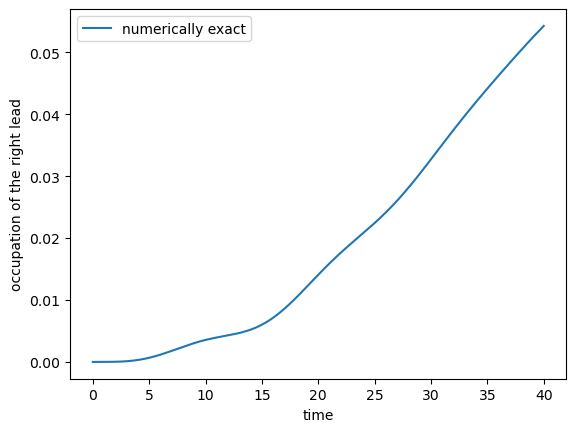

In [ ]:
import matplotlib.pyplot as plt
plt.plot(ed_list, J, label = 'numerically exact')
plt.legend()
plt.xlabel('time')
plt.ylabel('occupation of the right lead')